
Processing data_csvs/nisui_130_anti.txt...
--- Fit Results ---
Damping (gamma): 0.2791 ± 0.0006
Angular freq 1 (w1): 4.2075 ± 0.0103
Angular freq 2 (w2): 7.5744 ± 0.0006
Amplitude A: -7.3236 ± 0.1265
Amplitude B: 116.0710 ± 0.2075


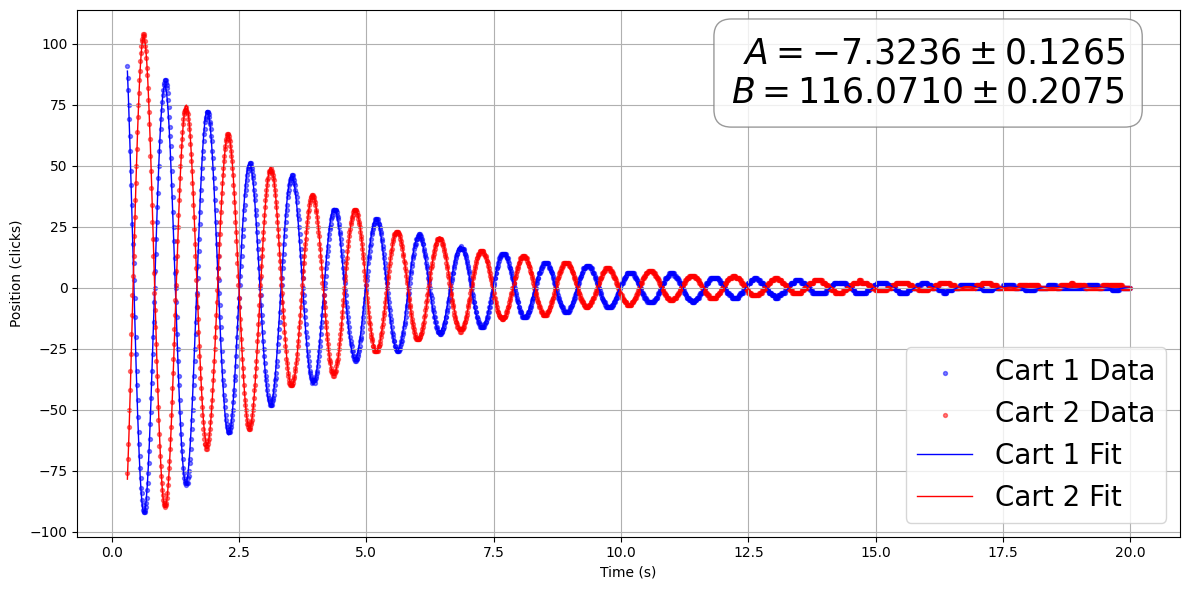


Processing data_csvs/nisui_80_anti.txt...
--- Fit Results ---
Damping (gamma): 0.2766 ± 0.0006
Angular freq 1 (w1): 4.3098 ± 0.0111
Angular freq 2 (w2): 7.5797 ± 0.0006
Amplitude A: 4.6865 ± 0.0882
Amplitude B: 79.4082 ± 0.1355


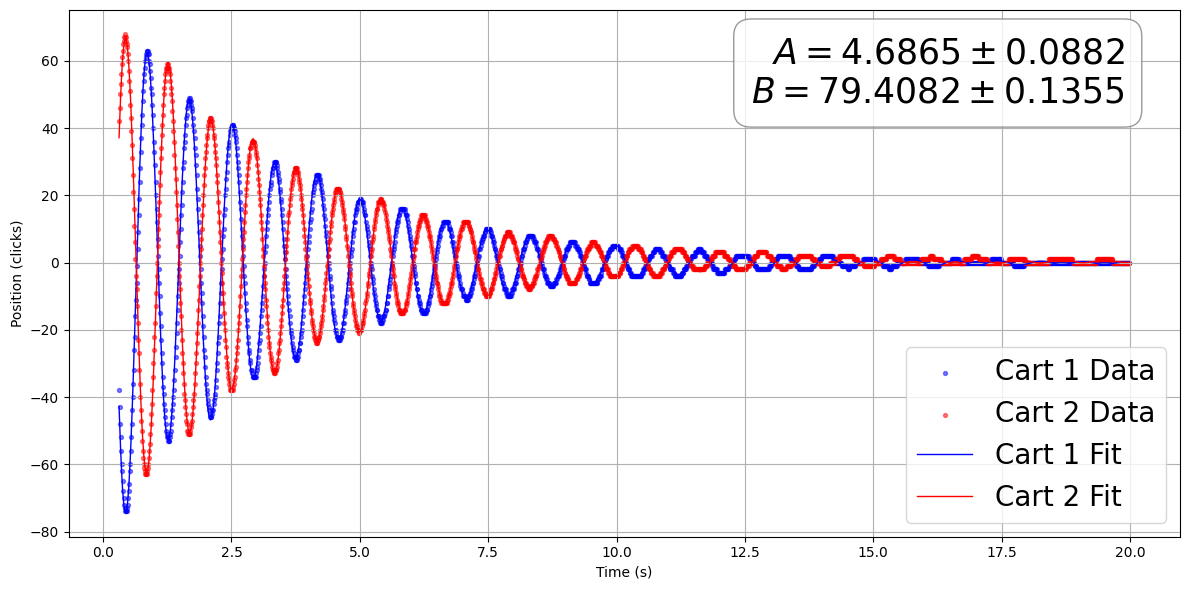


Processing data_csvs/nisui_110_same(1).txt...
--- Fit Results ---
Damping (gamma): 0.2670 ± 0.0005
Angular freq 1 (w1): 4.3043 ± 0.0004
Angular freq 2 (w2): 7.5534 ± 0.0178
Amplitude A: 117.8068 ± 0.1654
Amplitude B: 3.0184 ± 0.1022


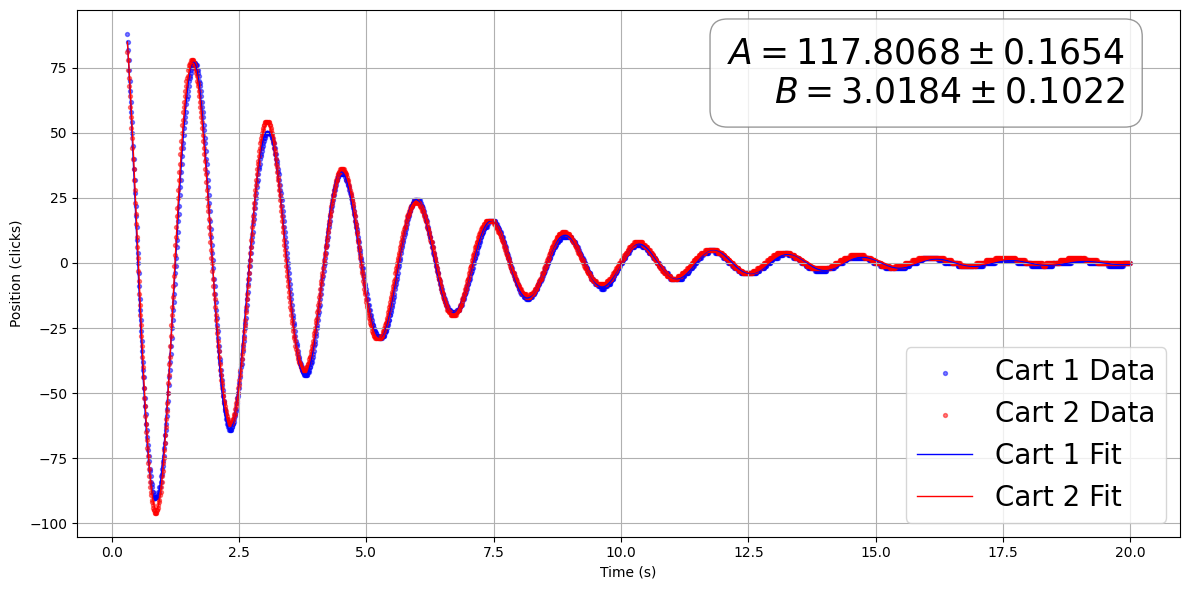


Processing data_csvs/nisui_100_anti.txt...
--- Fit Results ---
Damping (gamma): 0.2786 ± 0.0002
Angular freq 1 (w1): 7.5673 ± 0.0032
Angular freq 2 (w2): 7.5756 ± 0.0002
Amplitude A: 6.9841 ± 0.0400
Amplitude B: 101.5519 ± 0.0615


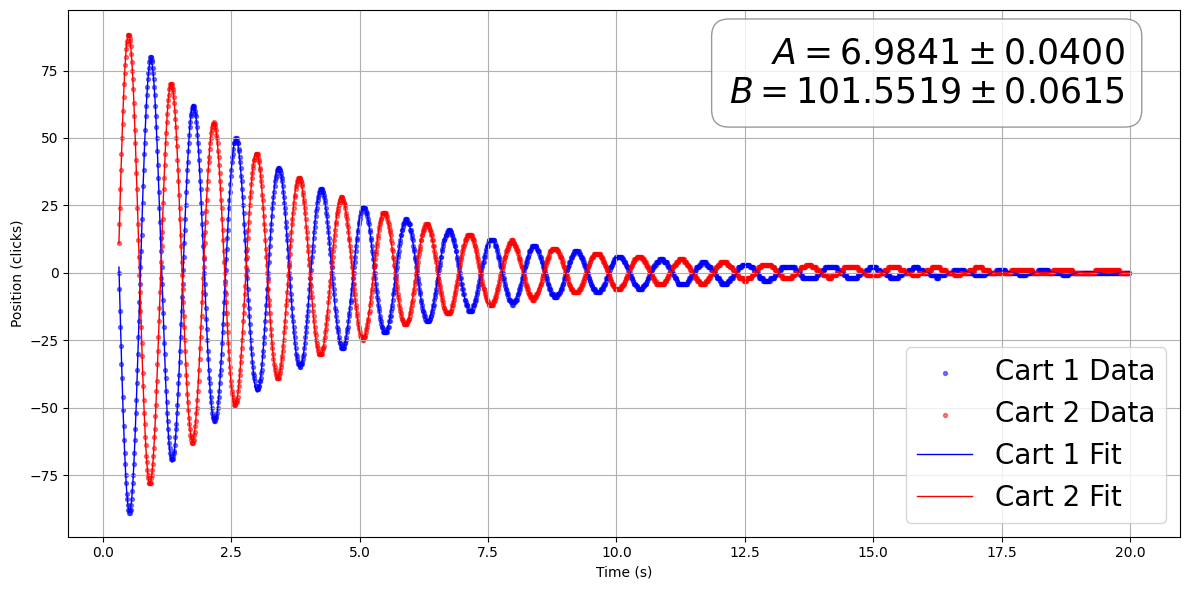


Processing data_csvs/nisui_1_fixed_fixed_same.txt...
--- Fit Results ---
Damping (gamma): 0.2659 ± 0.0005
Angular freq 1 (w1): 4.3097 ± 0.0004
Angular freq 2 (w2): 7.6075 ± 0.0351
Amplitude A: -107.3581 ± 0.1421
Amplitude B: 1.3572 ± 0.0919


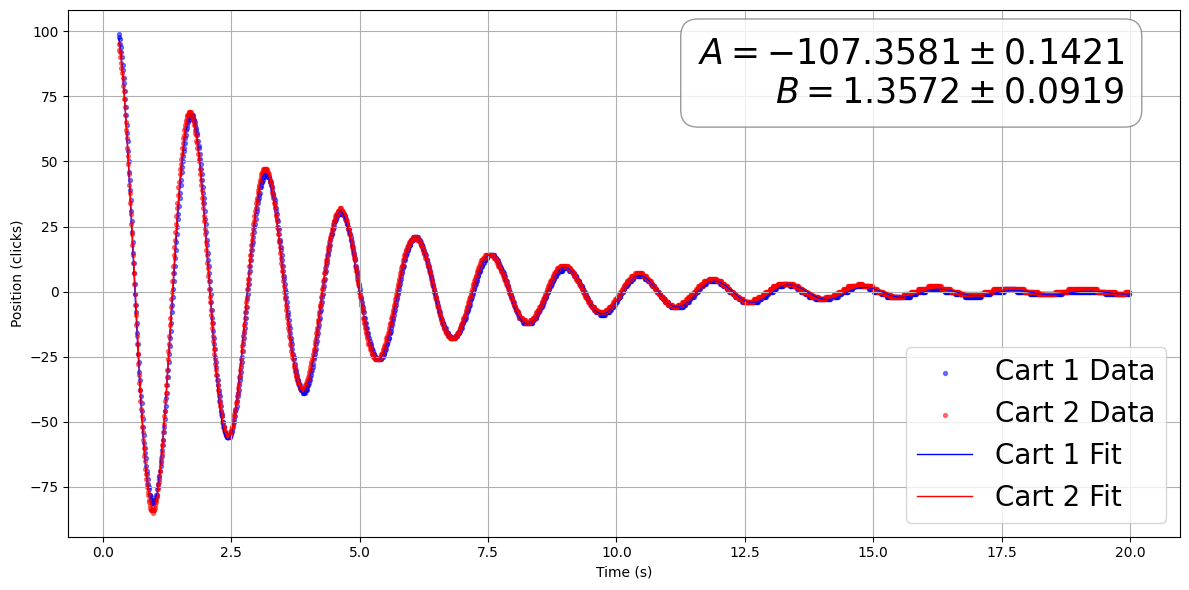


Processing data_csvs/nisui_80_same.txt...
--- Fit Results ---
Damping (gamma): 0.2677 ± 0.0005
Angular freq 1 (w1): 4.3107 ± 0.0005
Angular freq 2 (w2): 7.4390 ± 0.0182
Amplitude A: 82.7102 ± 0.1187
Amplitude B: 2.1886 ± 0.0719


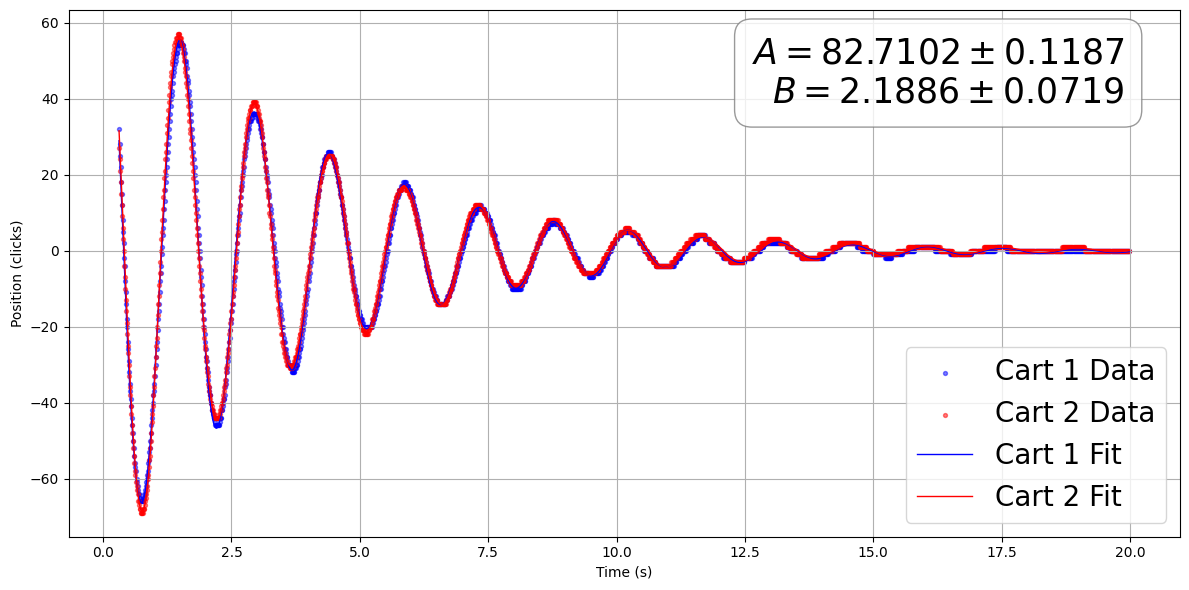


Processing data_csvs/nisui_1_fixed_same.txt...
--- Fit Results ---
Damping (gamma): 0.2659 ± 0.0003
Angular freq 1 (w1): 4.3092 ± 0.0002
Angular freq 2 (w2): 4.3689 ± 0.0057
Amplitude A: -103.7936 ± 0.0791
Amplitude B: 4.6601 ± 0.0471


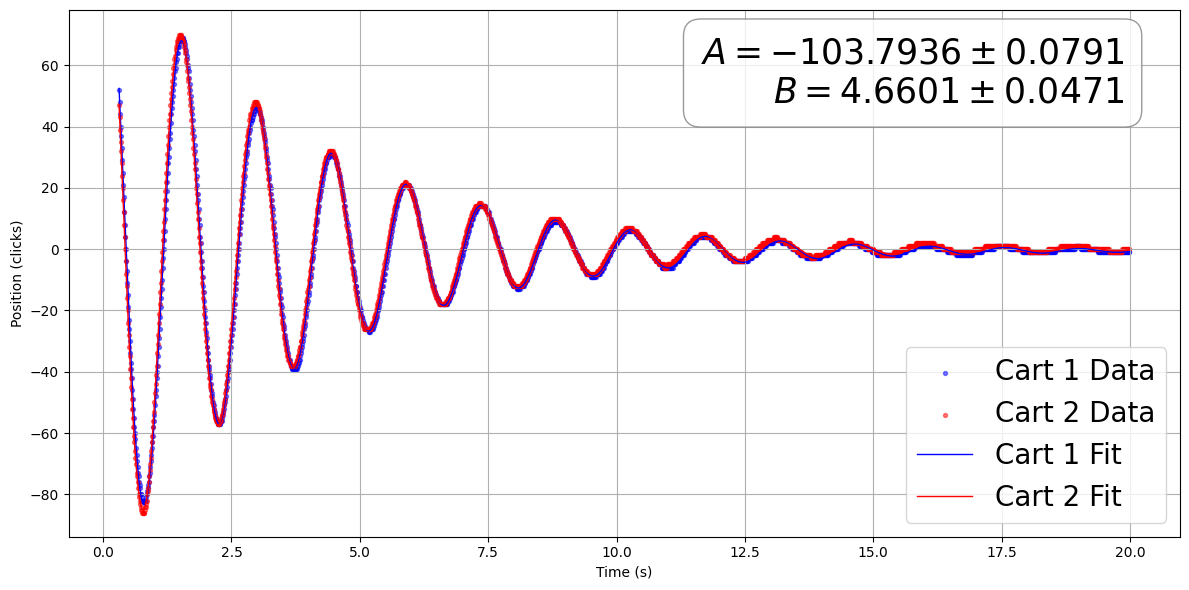


Processing data_csvs/nisui_120_anti.txt...
--- Fit Results ---
Damping (gamma): 0.2806 ± 0.0006
Angular freq 1 (w1): 4.1998 ± 0.0095
Angular freq 2 (w2): 7.5729 ± 0.0006
Amplitude A: -8.8348 ± 0.1411
Amplitude B: 131.9242 ± 0.2215


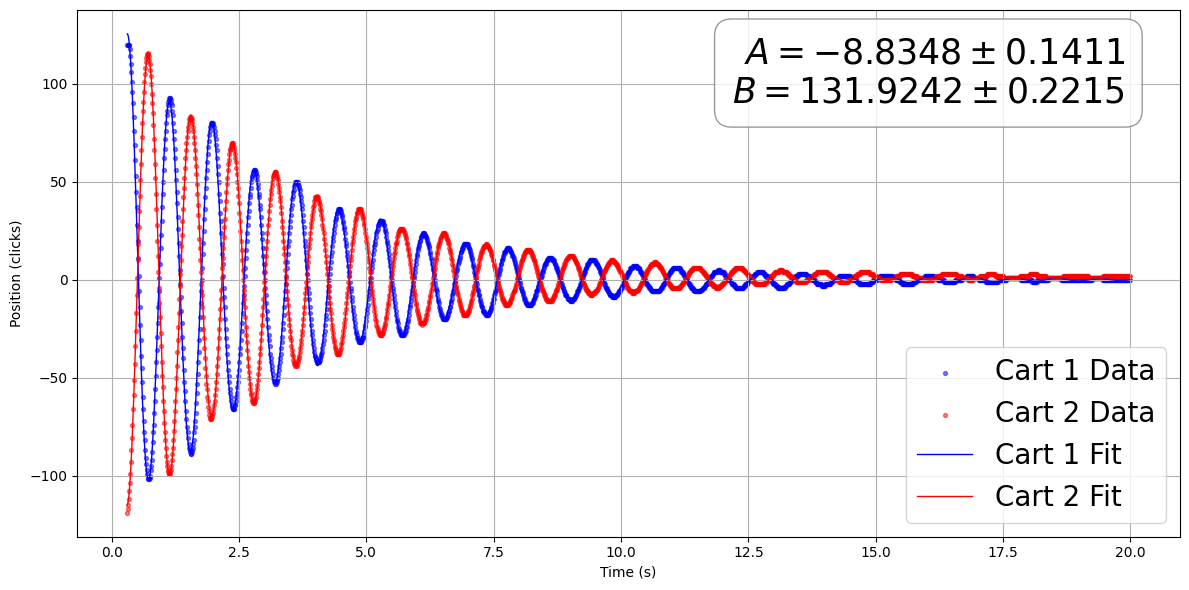


Processing data_csvs/nisui_90_anti.txt...
--- Fit Results ---
Damping (gamma): 0.2776 ± 0.0003
Angular freq 1 (w1): 7.5919 ± 0.0048
Angular freq 2 (w2): 7.5773 ± 0.0003
Amplitude A: -6.2225 ± 0.0517
Amplitude B: 94.7234 ± 0.0833


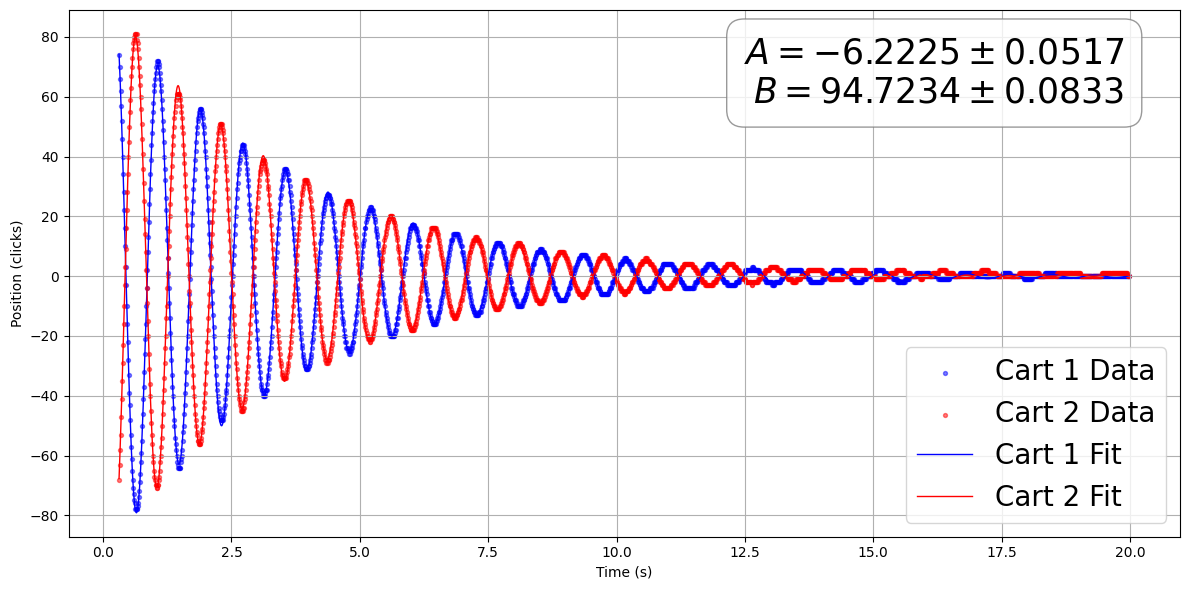


Processing data_csvs/nisui_120_same.txt...
--- Fit Results ---
Damping (gamma): 0.2675 ± 0.0005
Angular freq 1 (w1): 4.3028 ± 0.0005
Angular freq 2 (w2): 7.6458 ± 0.0213
Amplitude A: 140.9159 ± 0.1977
Amplitude B: 3.0288 ± 0.1240


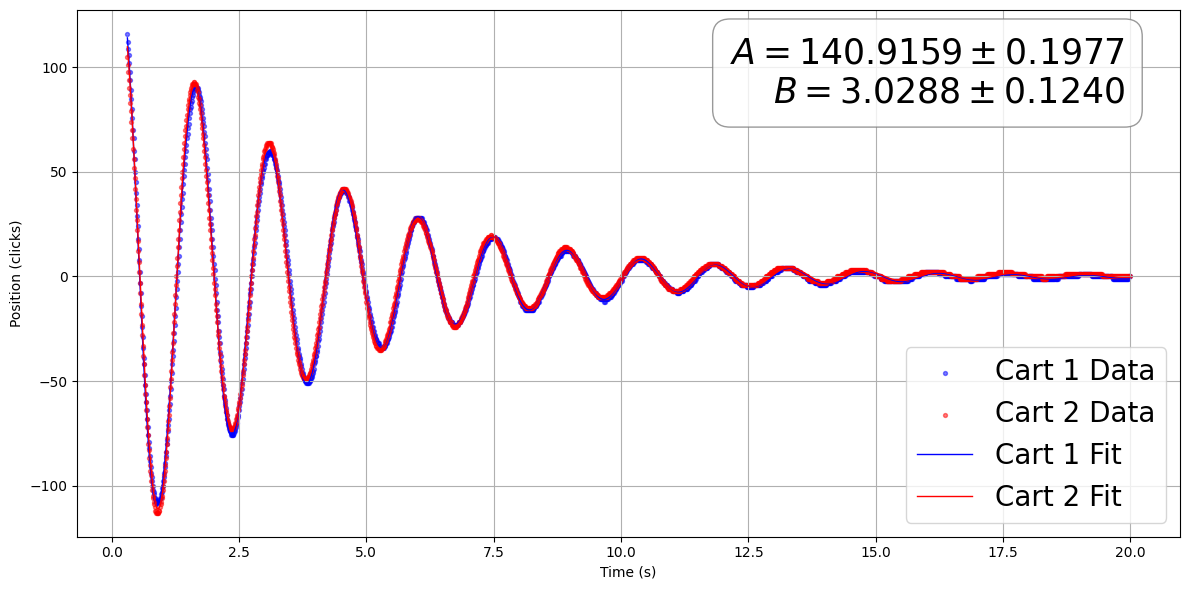

In [61]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

results_dict = []

# 1. Define the coupled equations to fit simultaneously
def coupled_oscillators(t_combo, gamma, w1, w2, A, B, phi1, phi2, C1, C2):
    N = len(t_combo) // 2
    t = t_combo[:N]

    # General solution for coupled damped oscillators
    x1 = np.exp(-gamma * t) * (A * np.cos(w1 * t + phi1) + B * np.cos(w2 * t + phi2)) + C1
    x2 = np.exp(-gamma * t) * (A * np.cos(w1 * t + phi1) - B * np.cos(w2 * t + phi2)) + C2

    return np.concatenate((x1, x2))

# 2. Load the data file
data_files = ["data_csvs/" + file for file in os.listdir("data_csvs") if file.endswith('.txt') or file.endswith('.csv')]

for data_file in data_files:
    print(f"\nProcessing {data_file}...")

    df = pd.read_csv(data_file, sep=r'\s+', comment='#', names=['index', 'time', 'cart1', 'cart2'])
    df = df[(df['time'] > 0.3) & (df['time'] < 20)]
    t = df['time'].values
    x1_data = df['cart1'].values
    x2_data = df['cart2'].values

    # Combine the data arrays for simultaneous fitting
    t_combo = np.concatenate((t, t))
    x_combo_data = np.concatenate((x1_data, x2_data))

    # 3. Provide initial guesses [gamma, w1, w2, A, B, phi1, phi2, C1, C2]
    initial_guess = [0.05, 5.0, 7.0, 10.0, 10.0, 0, 0, np.mean(x1_data), np.mean(x2_data)]

    fit_text = ""

    # 4. Perform the curve fit
    try:
        popt, pcov = curve_fit(coupled_oscillators, t_combo, x_combo_data, p0=initial_guess, maxfev=10000)

        # Unpack the fitted parameters
        gamma_fit, w1_fit, w2_fit, A_fit, B_fit, phi1_fit, phi2_fit, C1_fit, C2_fit = popt

        # Calculate standard deviation errors from the covariance matrix
        perr = np.sqrt(np.diag(pcov))
        gamma_err, w1_err, w2_err, A_err, B_err, phi1_err, phi2_err, C1_err, C2_err = perr

        print("--- Fit Results ---")
        print(f"Damping (gamma): {gamma_fit:.4f} ± {gamma_err:.4f}")
        print(f"Angular freq 1 (w1): {w1_fit:.4f} ± {w1_err:.4f}")
        print(f"Angular freq 2 (w2): {w2_fit:.4f} ± {w2_err:.4f}")
        print(f"Amplitude A: {A_fit:.4f} ± {A_err:.4f}")
        print(f"Amplitude B: {B_fit:.4f} ± {B_err:.4f}")

        # 5. Calculate fitted curves for plotting
        x1_fit = np.exp(-gamma_fit * t) * (A_fit * np.cos(w1_fit * t + phi1_fit) + B_fit * np.cos(w2_fit * t + phi2_fit)) + C1_fit
        x2_fit = np.exp(-gamma_fit * t) * (A_fit * np.cos(w1_fit * t + phi1_fit) - B_fit * np.cos(w2_fit * t + phi2_fit)) + C2_fit

        # Format text to display on the plot
        fit_text = (
            f"$A = {A_fit:.4f} \\pm {A_err:.4f}$\n"
            f"$B = {B_fit:.4f} \\pm {B_err:.4f}$"
        )

    except RuntimeError:
        print("Curve fit failed to converge. Try adjusting the initial_guess parameters.")
        x1_fit, x2_fit = None, None

    # 6. Plot the results
    plt.figure(figsize=(12, 6))

    # Plotting real data as faint scatter points so they remain secondary to the lines
    plt.scatter(t, x1_data, color='blue', alpha=0.5, s=8, label='Cart 1 Data')
    plt.scatter(t, x2_data, color='red', alpha=0.5, s=8, label='Cart 2 Data')

    if x1_fit is not None:
        # Plot solid lines for the curve fits over the scatter points
        plt.plot(t, x1_fit, color='blue', linestyle='-', linewidth=1, label='Cart 1 Fit')
        plt.plot(t, x2_fit, color='red', linestyle='-', linewidth=1, label='Cart 2 Fit')

        # Add the parameter and error text box to the plot
        plt.text(0.95, 0.95, fit_text, transform=plt.gca().transAxes,
                 fontsize=25, verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

    plt.xlabel('Time (s)')
    plt.ylabel('Position (clicks)')
    plt.legend(loc='lower right', fontsize=20)
    plt.grid(True)
    plt.tight_layout()

    # --- Directory and File Saving Logic ---
    data_file = data_file.split('/')[-1].replace(".txt", "").replace(".csv", "")
    type = 'anti' if "anti" in data_file else 'same'
    dir_path = f"figures/fit_curves/{type}"
    os.makedirs(dir_path, exist_ok=True)

    # Added .png extension so the image saves properly
    plt.savefig(os.path.join(dir_path, f"{data_file}.png"))

    fit_results_str = (
        f"--- Fit Results ---\n"
        f"Damping (gamma): {gamma_fit:.4f} ± {gamma_err:.4f}\n"
        f"Angular freq 1 (w1): {w1_fit:.4f} ± {w1_err:.4f}\n"
        f"Angular freq 2 (w2): {w2_fit:.4f} ± {w2_err:.4f}\n"
        f"Amplitude A: {A_fit:.4f} ± {A_err:.4f}\n"
        f"Amplitude B: {B_fit:.4f} ± {B_err:.4f}\n"
    )

    # Added .txt extension to the text file
    with open(os.path.join(dir_path, f"{data_file}_fit_results.txt"), "w", encoding="utf-8") as file:
        file.write(fit_results_str)

    results_dict.append((data_file, np.abs(A_fit), A_err, np.abs(B_fit), B_err, gamma_fit, gamma_err, w1_fit, w1_err, w2_fit, w2_err))

    plt.show()

## Handaling the max nisui


Processing nisui_120_same...
--- Fit Results ---
Damping (gamma): 0.2948 ± 0.0012
Angular freq 1 (w1): 1.2887 ± 0.0696
Angular freq 2 (w2): 7.5627 ± 0.0010
Amplitude A: 2.9663 ± 0.4211
Amplitude B: 212.6013 ± 0.9227


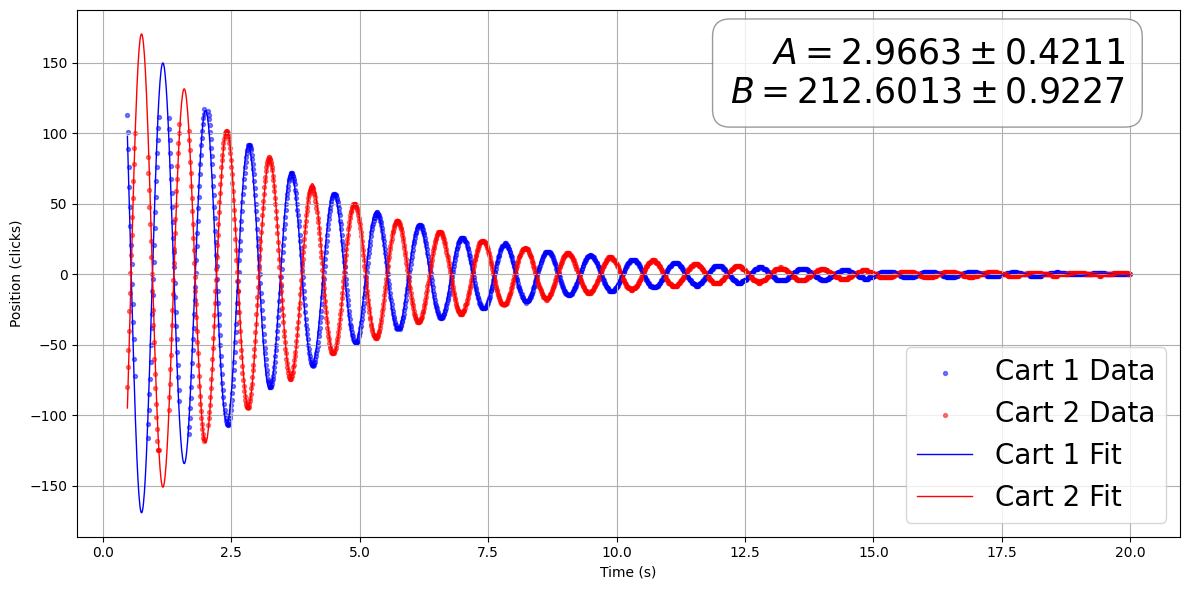

In [62]:
print(f"\nProcessing {data_file}...")


data_file = "nisui_max_anti.txt"

df = pd.read_csv(data_file, sep=r'\s+', comment='#', names=['index', 'time', 'cart1', 'cart2'])
df = df[(df['time'] > 0) & (df['time'] < 20)]
df = df[(df['cart1'] < 118) & (df['cart1'] > -118) & (df['cart2'] < 118) & (df['cart2'] > -118)]
t = df['time'].values
x1_data = df['cart1'].values
x2_data = df['cart2'].values - 8

# Combine the data arrays for simultaneous fitting
t_combo = np.concatenate((t, t))
x_combo_data = np.concatenate((x1_data, x2_data))

# 3. Provide initial guesses [gamma, w1, w2, A, B, phi1, phi2, C1, C2]
initial_guess = [0.05, 5.0, 7.0, 10.0, 10.0, 0, 0, np.mean(x1_data), np.mean(x2_data)]

fit_text = ""

# 4. Perform the curve fit
try:
    popt, pcov = curve_fit(coupled_oscillators, t_combo, x_combo_data, p0=initial_guess, maxfev=10000)

    # Unpack the fitted parameters
    gamma_fit, w1_fit, w2_fit, A_fit, B_fit, phi1_fit, phi2_fit, C1_fit, C2_fit = popt

    # Calculate standard deviation errors from the covariance matrix
    perr = np.sqrt(np.diag(pcov))
    gamma_err, w1_err, w2_err, A_err, B_err, phi1_err, phi2_err, C1_err, C2_err = perr

    print("--- Fit Results ---")
    print(f"Damping (gamma): {gamma_fit:.4f} ± {gamma_err:.4f}")
    print(f"Angular freq 1 (w1): {w1_fit:.4f} ± {w1_err:.4f}")
    print(f"Angular freq 2 (w2): {w2_fit:.4f} ± {w2_err:.4f}")
    print(f"Amplitude A: {A_fit:.4f} ± {A_err:.4f}")
    print(f"Amplitude B: {B_fit:.4f} ± {B_err:.4f}")

    # 5. Calculate fitted curves for plotting using a dense time array
    t_smooth = np.linspace(t.min(), t.max(), 2000) # 2000 points guarantees a smooth curve

    x1_fit = np.exp(-gamma_fit * t_smooth) * (A_fit * np.cos(w1_fit * t_smooth + phi1_fit) + B_fit * np.cos(w2_fit * t_smooth + phi2_fit)) + C1_fit
    x2_fit = np.exp(-gamma_fit * t_smooth) * (A_fit * np.cos(w1_fit * t_smooth + phi1_fit) - B_fit * np.cos(w2_fit * t_smooth + phi2_fit)) + C2_fit
    # Format text to display on the plot
    fit_text = (
        f"$A = {A_fit:.4f} \\pm {A_err:.4f}$\n"
        f"$B = {B_fit:.4f} \\pm {B_err:.4f}$"
    )

except RuntimeError:
    print("Curve fit failed to converge. Try adjusting the initial_guess parameters.")
    x1_fit, x2_fit = None, None

# 6. Plot the results
plt.figure(figsize=(12, 6))

# Plotting real data as faint scatter points so they remain secondary to the lines
plt.scatter(t, x1_data, color='blue', alpha=0.5, s=8, label='Cart 1 Data')
plt.scatter(t, x2_data, color='red', alpha=0.5, s=8, label='Cart 2 Data')

if x1_fit is not None:
    # Plot solid lines for the curve fits over the scatter points
    plt.plot(t_smooth, x1_fit, color='blue', linestyle='-', linewidth=1, label='Cart 1 Fit')
    plt.plot(t_smooth, x2_fit, color='red', linestyle='-', linewidth=1, label='Cart 2 Fit')

    # Add the parameter and error text box to the plot
    plt.text(0.95, 0.95, fit_text, transform=plt.gca().transAxes,
             fontsize=25, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.xlabel('Time (s)')
plt.ylabel('Position (clicks)')
plt.legend(loc='lower right', fontsize=20)
plt.grid(True)
plt.tight_layout()

# --- Directory and File Saving Logic ---
data_file = data_file.split('/')[-1].replace(".txt", "").replace(".csv", "")
type = 'anti' if "anti" in data_file else 'same'
dir_path = f"figures/fit_curves/{type}"
os.makedirs(dir_path, exist_ok=True)

# Added .png extension so the image saves properly
plt.savefig(os.path.join(dir_path, f"{data_file}.png"))

fit_results_str = (
    f"--- Fit Results ---\n"
    f"Damping (gamma): {gamma_fit:.4f} ± {gamma_err:.4f}\n"
    f"Angular freq 1 (w1): {w1_fit:.4f} ± {w1_err:.4f}\n"
    f"Angular freq 2 (w2): {w2_fit:.4f} ± {w2_err:.4f}\n"
    f"Amplitude A: {A_fit:.4f} ± {A_err:.4f}\n"
    f"Amplitude B: {B_fit:.4f} ± {B_err:.4f}\n"
)

# Added .txt extension to the text file
with open(os.path.join(dir_path, f"{data_file}_fit_results.txt"), "w", encoding="utf-8") as file:
    file.write(fit_results_str)

results_dict.append((data_file, np.abs(A_fit), A_err, np.abs(B_fit), B_err, gamma_fit, gamma_err, w1_fit, w1_err, w2_fit, w2_err))

plt.show()

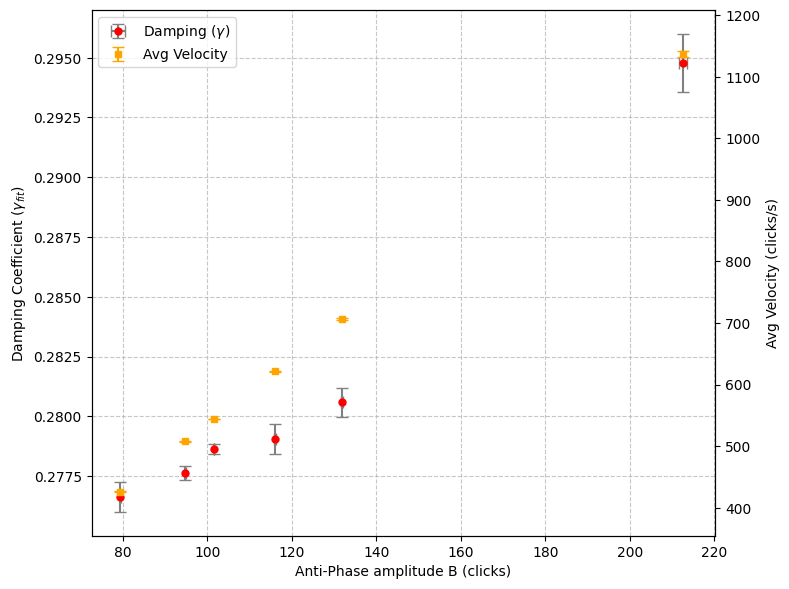

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 1. Convert your list of tuples into a Pandas DataFrame
columns = ['file_name', 'A_fit', 'A_err', 'B_fit', 'B_err', 'gamma_fit', 'gamma_err', 'w1_fit', 'w1_err', 'w2_fit', 'w2_err']
df = pd.DataFrame(results_dict, columns=columns)

# Calculate the average (RMS) velocity for both modes
df['v_avg_B'] = (df['B_fit'] * df['w2_fit']) / np.sqrt(2)

# --- Error Propagation for Velocity ---
# Formula: v_err = v_avg * sqrt((amp_err/amp)^2 + (w_err/w)^2)
df['v_err_B'] = df['v_avg_B'] * np.sqrt((df['B_err'] / df['B_fit'])**2 + (df['w2_err'] / df['w2_fit'])**2)

# 2. Filter the data to get only B dominant (Anti-Phase Mode)
df_B_dominant = df[df['B_fit'] > df['A_fit']]

# 3. Create a single plot
fig, ax = plt.subplots(figsize=(8, 6))

# ==========================================
# Plot: B is dominant (Anti-Phase Mode)
# ==========================================
# Primary Axis (Left - Gamma)
ax.errorbar(df_B_dominant['B_fit'], df_B_dominant['gamma_fit'],
             xerr=df_B_dominant['B_err'], yerr=df_B_dominant['gamma_err'],
             fmt='o', color='red', ecolor='gray', capsize=4, markersize=5, label=r'Damping ($\gamma$)')

ax.set_xlabel('Anti-Phase amplitude B (clicks)')
# Added the Y-label back here since it's a standalone chart now
ax.set_ylabel(r'Damping Coefficient ($\gamma_{fit}$)')
ax.tick_params(axis='y')
ax.grid(True, linestyle='--', alpha=0.7)

# Secondary Axis (Right - Velocity)
ax_twin = ax.twinx()
ax_twin.errorbar(df_B_dominant['B_fit'], df_B_dominant['v_avg_B'], yerr=df_B_dominant['v_err_B'],
                 fmt='s', color='orange', capsize=4, markersize=5, label='Avg Velocity')

ax_twin.set_ylabel('Avg Velocity (clicks/s)')
ax_twin.tick_params(axis='y')

# Combine legends
lines, labels = ax.get_legend_handles_labels()
lines_twin, labels_twin = ax_twin.get_legend_handles_labels()
ax.legend(lines + lines_twin, labels + labels_twin, loc='upper left')

# Automatically scale the twin axis symmetrically based on this data
vel_min, vel_max = df_B_dominant['v_avg_B'].min(), df_B_dominant['v_avg_B'].max()
padding = (vel_max - vel_min) * 0.1 if vel_max != vel_min else 1.0
ax_twin.set_ylim(vel_min - padding, vel_max + padding)

plt.tight_layout()
plt.show()

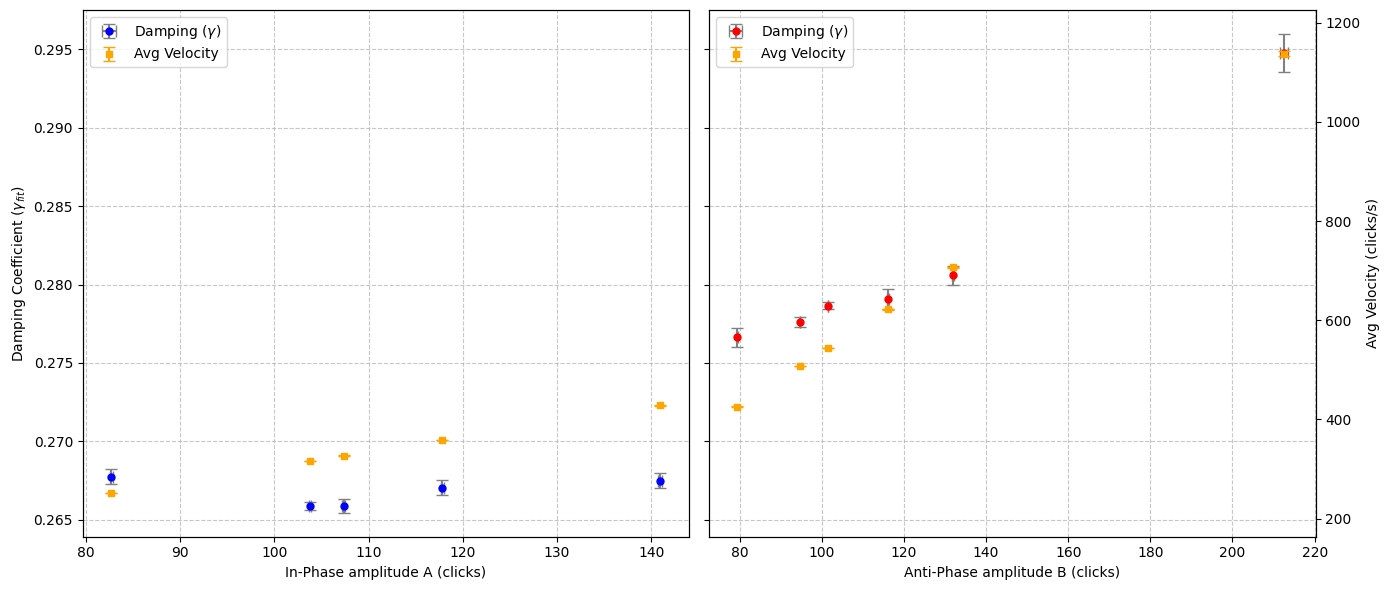

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 1. Convert your list of tuples into a Pandas DataFrame
columns = ['file_name', 'A_fit', 'A_err', 'B_fit', 'B_err', 'gamma_fit', 'gamma_err', 'w1_fit', 'w1_err', 'w2_fit', 'w2_err']
df = pd.DataFrame(results_dict, columns=columns)

# Calculate the average (RMS) velocity for both modes
df['v_avg_A'] = (df['A_fit'] * df['w1_fit']) / np.sqrt(2)
df['v_avg_B'] = (df['B_fit'] * df['w2_fit']) / np.sqrt(2)

# --- Error Propagation for Velocity ---
# Formula: v_err = v_avg * sqrt((amp_err/amp)^2 + (w_err/w)^2)
df['v_err_A'] = df['v_avg_A'] * np.sqrt((df['A_err'] / df['A_fit'])**2 + (df['w1_err'] / df['w1_fit'])**2)
df['v_err_B'] = df['v_avg_B'] * np.sqrt((df['B_err'] / df['B_fit'])**2 + (df['w2_err'] / df['w2_fit'])**2)

# 2. Filter the data into two separate DataFrames based on dominance
df_A_dominant = df[df['A_fit'] > df['B_fit']]
df_B_dominant = df[df['B_fit'] > df['A_fit']]

# 3. Create the plots side-by-side (sharey shared on left axes)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ==========================================
# Plot 1: A is dominant (In-Phase Mode)
# ==========================================
# Primary Axis (Left - Gamma)
ax1.errorbar(df_A_dominant['A_fit'], df_A_dominant['gamma_fit'],
             xerr=df_A_dominant['A_err'], yerr=df_A_dominant['gamma_err'],
             fmt='o', color='blue', ecolor='gray', capsize=4, markersize=5, label=r'Damping ($\gamma$)')
ax1.set_xlabel('In-Phase amplitude A (clicks)')
ax1.set_ylabel(r'Damping Coefficient ($\gamma_{fit}$)')
ax1.tick_params(axis='y')
ax1.grid(True, linestyle='--', alpha=0.7)

# Secondary Axis (Right - Velocity)
ax1_twin = ax1.twinx()
ax1_twin.errorbar(df_A_dominant['A_fit'], df_A_dominant['v_avg_A'], yerr=df_A_dominant['v_err_A'],
                 fmt='s', color='orange', capsize=4, markersize=5, label='Avg Velocity')
# Hide ticks and labels on the middle twin axis to keep it clean
ax1_twin.tick_params(axis='y', labelleft=False, labelright=False, left=False, right=False)

# Combine legends for ax1 -> Moved to upper left
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_1_twin, labels_1_twin = ax1_twin.get_legend_handles_labels()
ax1.legend(lines_1 + lines_1_twin, labels_1 + labels_1_twin, loc='upper left')

# ==========================================
# Plot 2: B is dominant (Anti-Phase Mode)
# ==========================================
# Primary Axis (Left - Gamma)
ax2.errorbar(df_B_dominant['B_fit'], df_B_dominant['gamma_fit'],
             xerr=df_B_dominant['B_err'], yerr=df_B_dominant['gamma_err'],
             fmt='o', color='red', ecolor='gray', capsize=4, markersize=5, label=r'Damping ($\gamma$)')
ax2.set_xlabel('Anti-Phase amplitude B (clicks)')
ax2.tick_params(axis='y', labelcolor='red')
ax2.grid(True, linestyle='--', alpha=0.7)

# Secondary Axis (Right - Velocity) -> Fixed via .sharey() method!
ax2_twin = ax2.twinx()
ax2_twin.sharey(ax1_twin)
ax2_twin.errorbar(df_B_dominant['B_fit'], df_B_dominant['v_avg_B'], yerr=df_B_dominant['v_err_B'],
                 fmt='s', color='orange', capsize=4, markersize=5, label='Avg Velocity')

# Set the label ONLY on the rightmost Y axis
ax2_twin.set_ylabel('Avg Velocity (clicks/s)')
ax2_twin.tick_params(axis='y')

# Combine legends for ax2 -> Keep at upper left
lines_2, labels_2 = ax2.get_legend_handles_labels()
lines_2_twin, labels_2_twin = ax2_twin.get_legend_handles_labels()
ax2.legend(lines_2 + lines_2_twin, labels_2 + labels_2_twin, loc='upper left')

# Automatically scale both twin axes symmetrically based on combined data bounds
all_v = pd.concat([df_A_dominant['v_avg_A'], df_B_dominant['v_avg_B']])
vel_min, vel_max = all_v.min(), all_v.max()
padding = (vel_max - vel_min) * 0.1 if vel_max != vel_min else 1.0
ax2_twin.set_ylim(vel_min - padding, vel_max + padding)

plt.tight_layout()
plt.show()